<a href="https://colab.research.google.com/github/raviradadiya1414/Diabetes_Dataset_Modeling/blob/main/Diabetes_Dataset_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score

In [ ]:
df = pd.read_csv('/content/diabetes.csv')
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.groupby('Outcome')['Glucose'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,109.980000,26.141200,0.0,93.0,107.0,125.0,197.0
1,268.0,141.257463,31.939622,0.0,119.0,140.0,167.0,199.0


In [ ]:
df.groupby('Outcome')['Insulin'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,68.792000,98.865289,0.0,0.0,39.0,105.00,744.0
1,268.0,100.335821,138.689125,0.0,0.0,0.0,167.25,846.0


In [ ]:
data = df.corr()
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

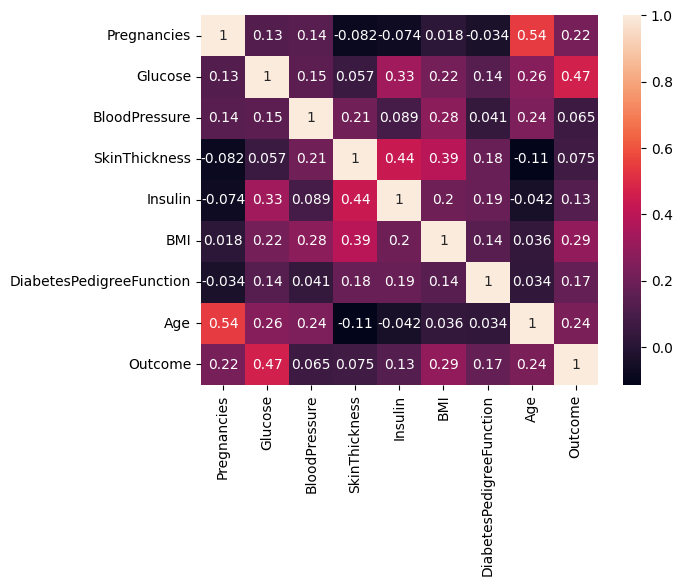

In [ ]:
sns.heatmap(data,annot=True)

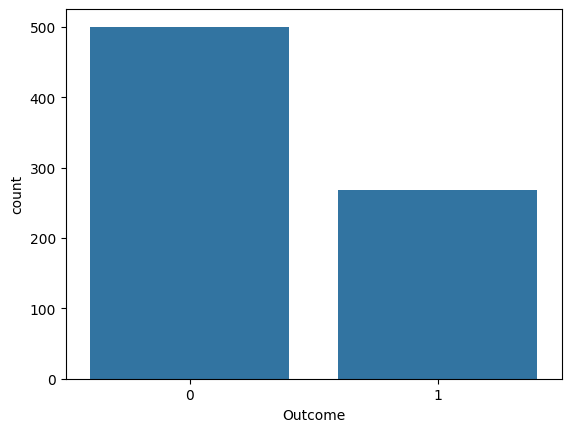

In [ ]:
sns.countplot(x='Outcome',data=df)
plt.show()

<Axes: xlabel='Glucose', ylabel='Count'>

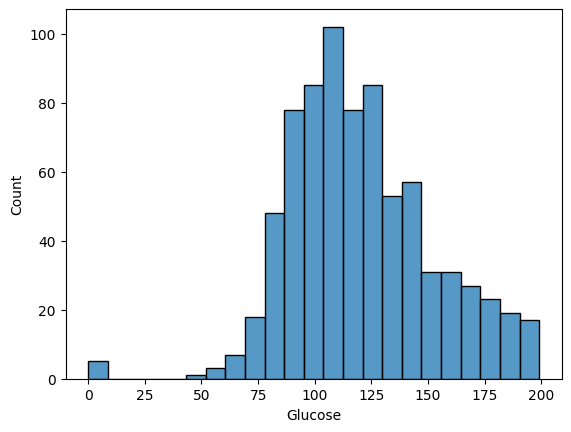

In [ ]:
sns.histplot(df['Glucose'])

<Axes: xlabel='Pregnancies', ylabel='Count'>

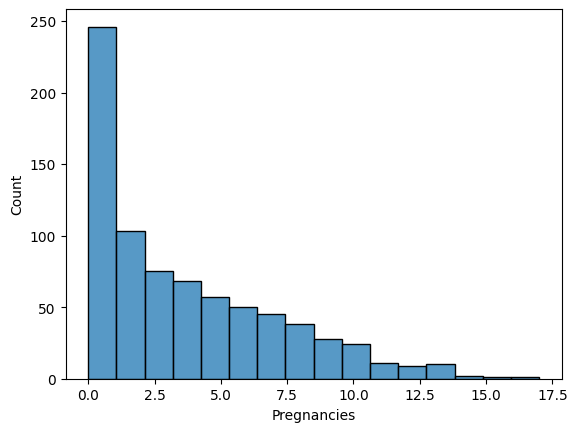

In [ ]:
sns.histplot(df['Pregnancies'])

In [ ]:
x = df.drop(columns='Outcome',axis=1)
y = df['Outcome']

In [ ]:
scaler = MinMaxScaler()
scaler.fit(x)
x = scaler.transform(x)

In [ ]:
x[0]

array([0.35294118, 0.74371859, 0.59016393, 0.35353535, 0.        ,
       0.50074516, 0.23441503, 0.48333333])

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score

In [ ]:
models = ['svm','LogisticRegression','RandomForestClassifier','MultinomialNB','DecisionTreeClassifier','KNeighborsClassifier']

In [ ]:
model_1 = svm.SVC()
model_2 = LogisticRegression()
model_3 = RandomForestClassifier()
model_4 = MultinomialNB()
model_5 = DecisionTreeClassifier()
model_6 = KNeighborsClassifier(n_neighbors=20)


In [ ]:
accuracy = []
f1 = []
recall = []

In [ ]:
def model_fit(model,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test):
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  accuracy.append(accuracy_score(y_test,y_pred))
  f1.append(f1_score(y_test,y_pred))
  recall.append(recall_score(y_test,y_pred))

  sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
  print(model)
  print(f'Accuracy is : {accuracy} , Recall is : {recall} ,F1 is : {f1}')
  plt.show()


SVC()
Accuracy is : [0.7987012987012987] , Recall is : [0.5818181818181818] ,F1 is : [0.6736842105263158]


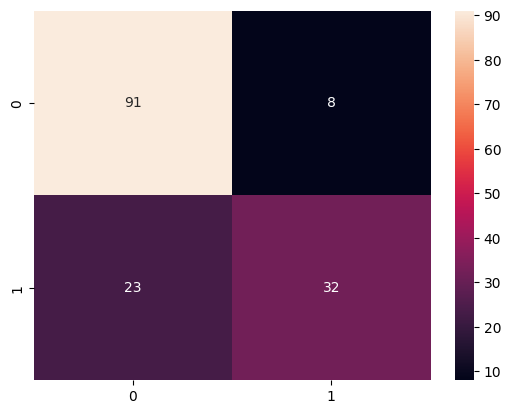

In [ ]:
model_fit(model_1)

LogisticRegression()
Accuracy is : [0.7987012987012987, 0.7727272727272727] , Recall is : [0.5818181818181818, 0.509090909090909] ,F1 is : [0.6736842105263158, 0.6153846153846154]


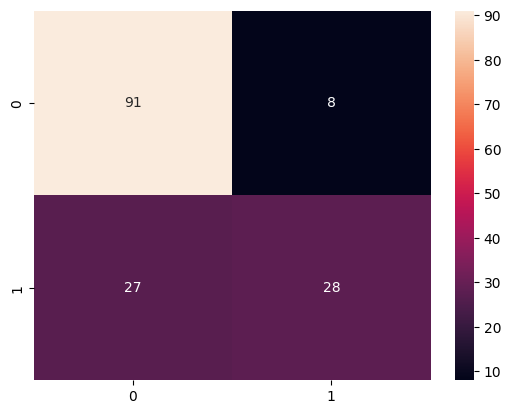

In [ ]:
model_fit(model_2)

RandomForestClassifier()
Accuracy is : [0.7987012987012987, 0.7727272727272727, 0.8051948051948052] , Recall is : [0.5818181818181818, 0.509090909090909, 0.6363636363636364] ,F1 is : [0.6736842105263158, 0.6153846153846154, 0.7]


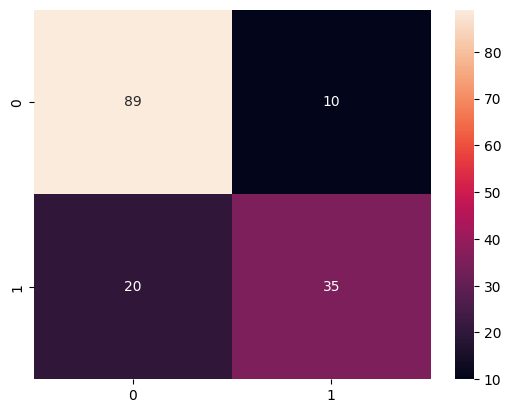

In [ ]:
model_fit(model_3)

MultinomialNB()
Accuracy is : [0.7987012987012987, 0.7727272727272727, 0.8051948051948052, 0.6428571428571429] , Recall is : [0.5818181818181818, 0.509090909090909, 0.6363636363636364, 0.0] ,F1 is : [0.6736842105263158, 0.6153846153846154, 0.7, 0.0]


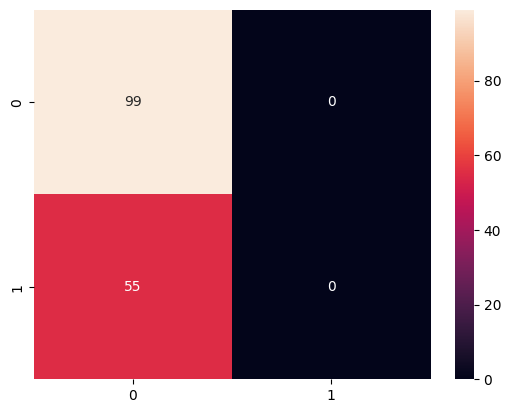

In [ ]:
model_fit(model_4)

DecisionTreeClassifier()
Accuracy is : [0.7987012987012987, 0.7727272727272727, 0.8051948051948052, 0.6428571428571429, 0.6948051948051948] , Recall is : [0.5818181818181818, 0.509090909090909, 0.6363636363636364, 0.0, 0.5818181818181818] ,F1 is : [0.6736842105263158, 0.6153846153846154, 0.7, 0.0, 0.5765765765765766]


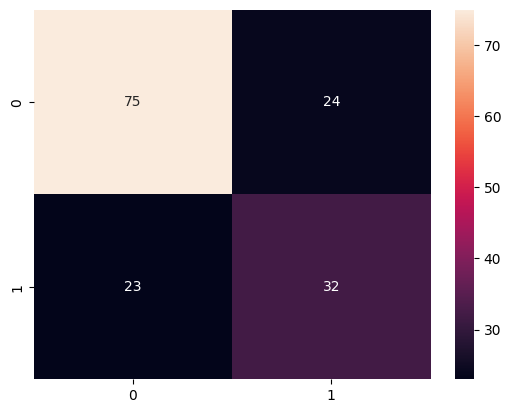

In [ ]:
model_fit(model_5)

KNeighborsClassifier(n_neighbors=20)
Accuracy is : [0.7987012987012987, 0.7727272727272727, 0.8051948051948052, 0.6428571428571429, 0.6948051948051948, 0.7792207792207793] , Recall is : [0.5818181818181818, 0.509090909090909, 0.6363636363636364, 0.0, 0.5818181818181818, 0.509090909090909] ,F1 is : [0.6736842105263158, 0.6153846153846154, 0.7, 0.0, 0.5765765765765766, 0.6222222222222222]


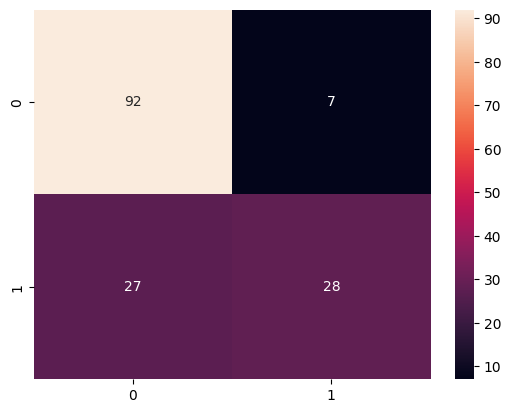

In [ ]:
model_fit(model_6)

In [ ]:
table = pd.DataFrame(data={
    'models':models,
    'accuracy':accuracy,
    'f1':f1,
    'recall':recall
})
table

,models,accuracy,f1,recall
0,svm,0.798701,0.673684,0.581818
1,LogisticRegression,0.772727,0.615385,0.509091
2,RandomForestClassifier,0.805195,0.700000,0.636364
3,MultinomialNB,0.642857,0.000000,0.000000
4,DecisionTreeClassifier,0.694805,0.576577,0.581818
5,KNeighborsClassifier,0.779221,0.622222,0.509091


In [ ]:
table['accuracy'].max()

0.8051948051948052

<Axes: >

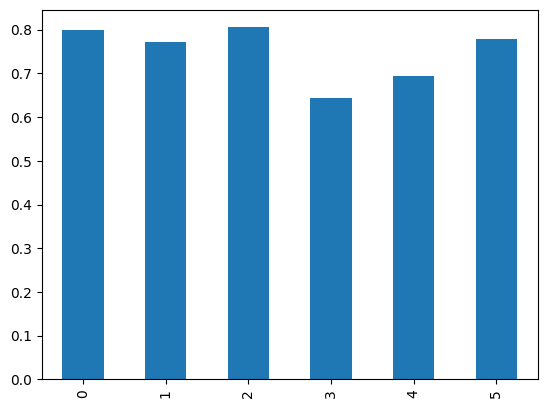

In [ ]:
table['accuracy'].plot(kind='bar')

In [ ]:
def pre_data(Data,model=model_3):
  Data = np.array(Data).reshape(1,-1)
  data = scaler.transform(Data)
  pre = model.predict(data)
  if pre[0] == 0:
    print('Non-Diabetic')
  else:
    print('Diabetic')



In [ ]:
df.loc[5]

,5
Pregnancies,5.000
Glucose,116.000
BloodPressure,74.000
SkinThickness,0.000
Insulin,0.000
BMI,25.600
DiabetesPedigreeFunction,0.201
Age,30.000
Outcome,0.000


In [ ]:
pre_data([25,122,74,0,0,25,0,30])

Non-Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
pre_data([6,	148,	72,	35,	0,	33.6,	0.627,50])

Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
